In [ ]:

import torch
from diffusers.utils import load_image
from diffusers import StableDiffusionXLControlNetImg2ImgPipeline, ControlNetModel, AutoencoderKL
from src.common.load_lora import load_emolora
from src.common.util import resize_img, color_fix
from src.common.controlnet_detector import canny_detector, tile_detector

/data/mj/style3d/embroidery_customization-impl/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
SDXL = "stabilityai/stable-diffusion-xl-base-1.0"
VAE = "madebyollin/sdxl-vae-fp16-fix"
CANNY = "xinsir/controlnet-canny-sdxl-1.0"
TILE = "xinsir/controlnet-tile-sdxl-1.0"

DEVICE = "cuda"
DTYPE = torch.float16

In [4]:
# Load Pipeline

controlnet_canny = ControlNetModel.from_pretrained(CANNY, torch_dtype=DTYPE)
controlnet_tile = ControlNetModel.from_pretrained(TILE, torch_dtype=DTYPE)
vae = AutoencoderKL.from_pretrained(VAE, torch_dtype=DTYPE)
pipeline = StableDiffusionXLControlNetImg2ImgPipeline.from_pretrained(
    SDXL,
    vae=vae,
    controlnet=[controlnet_canny, controlnet_tile],
    torch_dtype=DTYPE,
).to(DEVICE)

Loading pipeline components...: 100%|██████████| 7/7 [02:23<00:00, 20.50s/it]


In [5]:
# Input Image

input_image_path = "assets/inputs/design_4.png"
input_image = load_image(input_image_path)
resized_image = resize_img(input_image)
canny_map = canny_detector(resized_image)
tile_map = tile_detector(resized_image, blur_strength=15)
controlnet_img = [canny_map, tile_map]

100%|██████████| 28/28 [00:07<00:00,  3.98it/s]


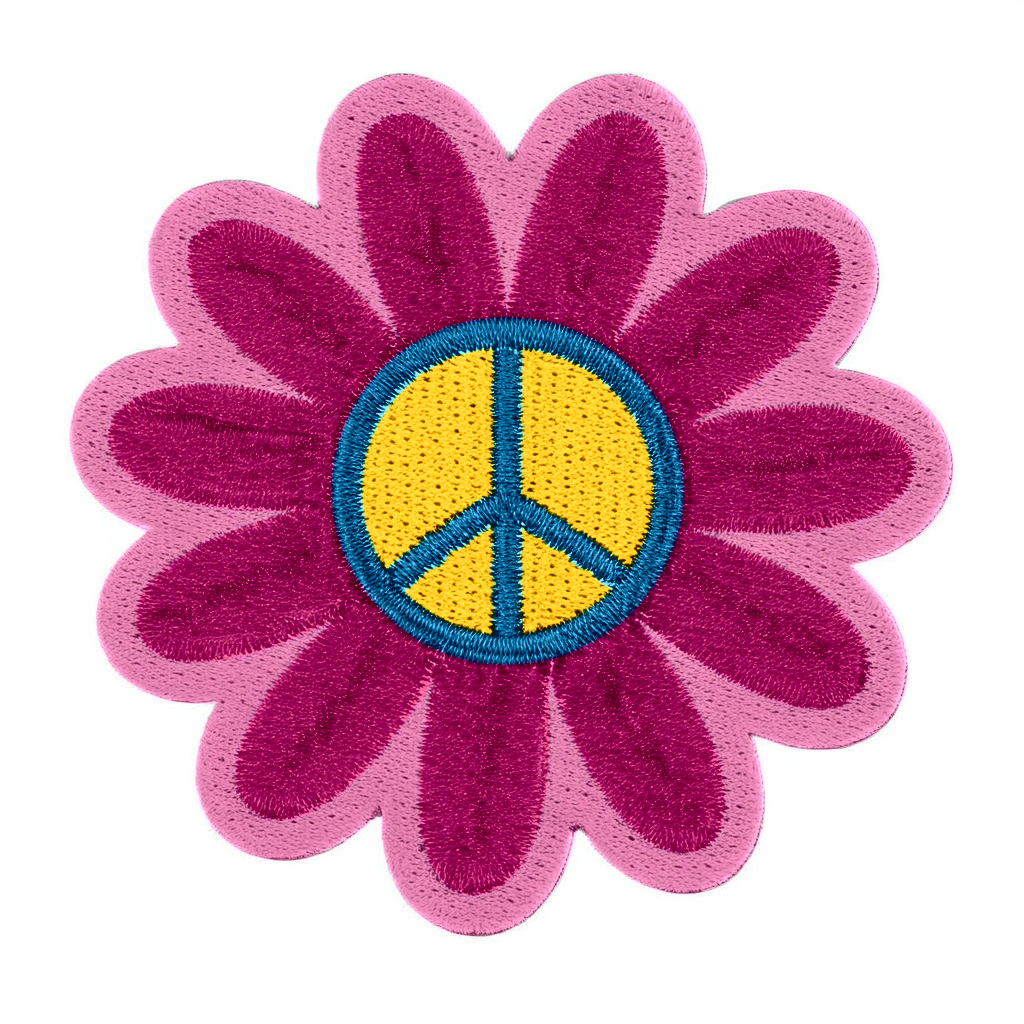

In [6]:
# Flat Embroidery Example
lora_path = "models/7009bc24.safetensors"
pipeline = load_emolora(pipeline, lora_path)

lora_scale = 1.0
canny_scale = 0.5
tile_scale = 0.5
denoise = 0.95
num_images_per_prompt = 1

generator = torch.Generator(DEVICE).manual_seed(42)
images = pipeline(
    prompt="in [emb] style",
    negative_prompt="lowres, bad anatomy, cropped, worst quality, low quality",
    image=resized_image,
    control_image=controlnet_img,
    num_inference_steps=30,
    guidance_scale=7,
    cross_attention_kwargs={"scale": lora_scale},
    controlnet_conditioning_scale=[canny_scale, tile_scale],
    strength=denoise,
    num_images_per_prompt=num_images_per_prompt,
    generator=generator
).images

if canny_scale >= 0.5:
    images = [color_fix(img, resized_image) for img in images]

images[0]

100%|██████████| 25/25 [00:05<00:00,  4.25it/s]


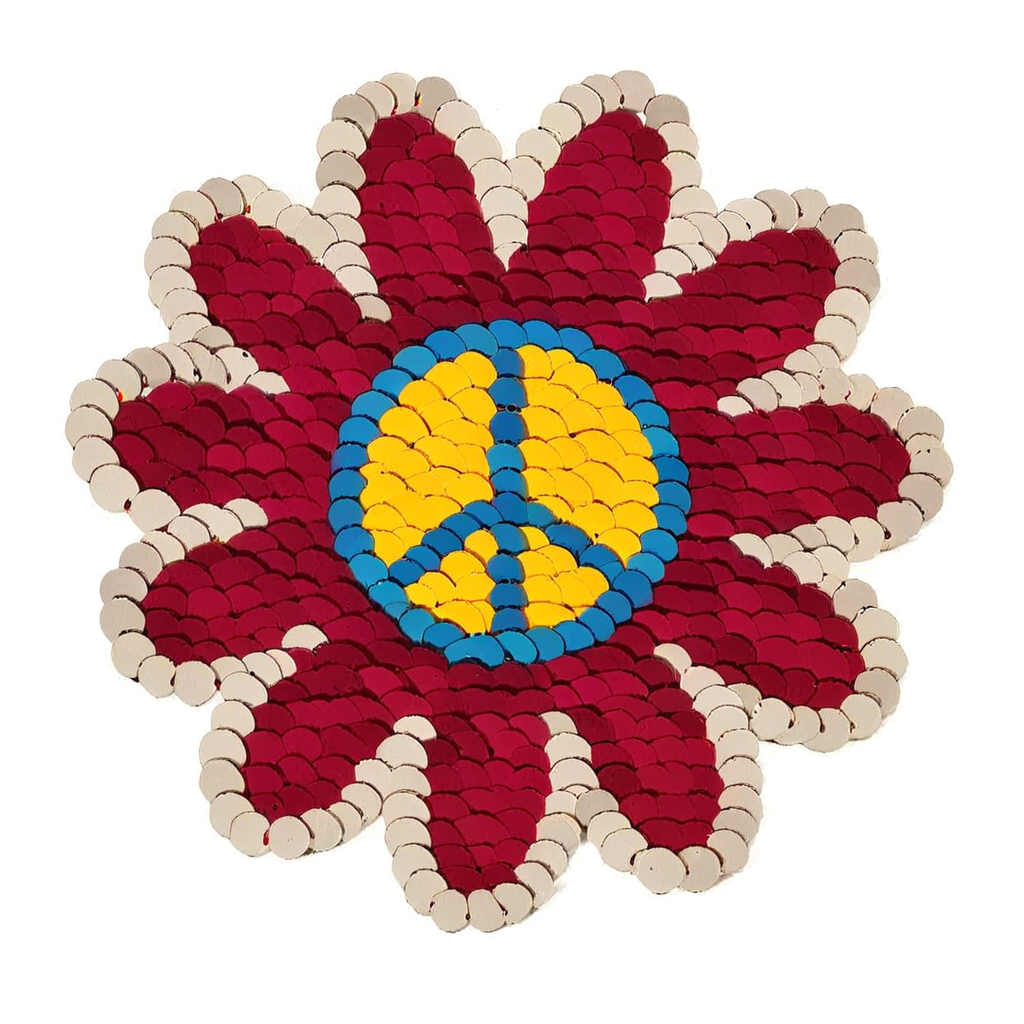

In [7]:
# Sequin Embroidery Example
lora_path = "models/08b05561.safetensors"
pipeline = load_emolora(pipeline, lora_path)

lora_scale = 1.0
canny_scale = 0
tile_scale = 0.4
denoise = 0.85
num_images_per_prompt = 1

generator = torch.Generator(DEVICE).manual_seed(-1)
images = pipeline(
    prompt="in [emb] style",
    negative_prompt="lowres, bad anatomy, cropped, worst quality, low quality",
    image=resized_image,
    control_image=controlnet_img,
    num_inference_steps=30,
    guidance_scale=7,
    cross_attention_kwargs={"scale": lora_scale},
    controlnet_conditioning_scale=[canny_scale, tile_scale],
    strength=denoise,
    num_images_per_prompt=num_images_per_prompt,
    generator=generator
).images

images[0]